# Peaky Syndexer

This notebook exercises the full synthetic LIBS pipeline on increasingly dense mixtures:

1. Synthesize spectra with `PeakyMaker`
2. Detect and fit peaks with `PeakyFinder`
3. Recover species and plasma state with `PeakyIndexer`

The checks below are intentionally practical rather than idealized. For the clean blend we check exact dominant species. For denser blends we verify that the intended species appear among the top-ranked fit weights and that the recovered temperature / electron density stay close to the synthesis inputs.

The full-range cases use `180-961 nm` with `0.02 nm` sampling. A coarser `0.05 nm` grid under-resolves the synthetic peak structure enough that the peak-finder stress test becomes misleading.

`FitResult.concentrations` are normalized fit weights, so the ranking is used here as a species-recovery heuristic rather than a calibrated abundance estimate.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from alibz import PeakyFinder, PeakyIndexer, PeakyMaker


In [2]:
TEMPERATURE = 10_000.0
LOG_NE = 17.0

ROMAN = {1: "I", 2: "II", 3: "III", 4: "IV"}

maker = PeakyMaker("db")
finder = PeakyFinder.__new__(PeakyFinder)


def build_fraction_vector(composition):
    fracs = np.zeros(maker.max_z, dtype=float)
    for element, fraction in composition.items():
        fracs[maker.db.elements.index(element)] = fraction
    return fracs


def species_label(element, ion):
    return f"{element} {ROMAN.get(ion, str(ion))}"


def rank_species(result):
    ranked = []
    for idx in np.argsort(result.concentrations)[::-1]:
        weight = float(result.concentrations[idx])
        if weight <= 0:
            continue
        species = result.species[idx]
        ranked.append((species.element, species.ion, weight))
    return ranked


def unique_ranked_species(ranked, top_n):
    seen = set()
    ordered = []
    for element, ion, weight in ranked:
        key = (element, ion)
        if key in seen:
            continue
        seen.add(key)
        ordered.append((element, ion, weight))
        if len(ordered) >= top_n:
            break
    return ordered


def assigned_species(result):
    return sorted(
        {
            (assignment["element"], assignment["ion"])
            for assignment in result.peak_assignments
            if assignment["element"] is not None
        }
    )


def run_case(case):
    x, y, _ = maker.peak_maker(
        build_fraction_vector(case["composition"]),
        w_lo=case["w_lo"],
        w_hi=case["w_hi"],
        inc=case["inc"],
        voigt_sig=case["sigma"],
        voigt_gam=case["gamma"],
        temperature=TEMPERATURE,
        ne=LOG_NE,
    )

    fit = finder.fit_spectrum(
        x,
        y,
        subtract_background=False,
        plot=False,
        n_sigma=0,
    )
    peaks = fit["sorted_parameter_array"]

    indexer = PeakyIndexer(peaks, temperature_init=TEMPERATURE, ne_init=LOG_NE)
    result = indexer.run(
        shift_tolerance=0.05,
        max_ion_stage=2,
        T_bounds=(9_000.0, 11_000.0),
        ne_bounds=(16.7, 17.3),
        sigma_bounds=(0.02, 0.05),
        gamma_bounds=(0.01, 0.04),
        n_calls=case["n_calls"],
        verbose=False,
    )

    return {
        "x": x,
        "y": y,
        "fit": fit,
        "peaks": peaks,
        "result": result,
        "ranked": rank_species(result),
        "assigned": assigned_species(result),
    }


def summarize_case(case, run):
    result = run["result"]
    top_species = ", ".join(
        f"{species_label(element, ion)} ({weight:.2e})"
        for element, ion, weight in unique_ranked_species(run["ranked"], case["top_n"])
    )
    assigned = ", ".join(species_label(element, ion) for element, ion in run["assigned"][:12])
    print(case["name"])
    print(f"  composition={case['composition']}")
    print(f"  peaks={run['peaks'].shape[0]}  R^2={result.r_squared:.6f}")
    print(f"  T={result.temperature:.1f} K  log10(ne)={result.ne:.3f}")
    print(f"  active species={len(run['ranked'])}  assigned species={len(run['assigned'])}")
    print(f"  top species: {top_species}")
    print(f"  assigned species: {assigned}")


def validate_case(case, run):
    result = run["result"]
    top_species = {
        (element, ion)
        for element, ion, _ in unique_ranked_species(run["ranked"], case["top_n"])
    }
    checks = {
        "enough_peaks": run["peaks"].shape[0] >= case["min_peaks"],
        "species_recovered": set(case["expected_species"]).issubset(top_species),
        "r_squared": result.r_squared > 0.99,
        "temperature": abs(result.temperature - TEMPERATURE) <= case["temperature_tol"],
        "electron_density": abs(result.ne - LOG_NE) <= case["ne_tol"],
    }
    failures = [name for name, passed in checks.items() if not passed]
    if failures:
        raise AssertionError(f"{case['name']} failed checks: {', '.join(failures)}")
    return checks


def plot_case(case, run, ax):
    x = run["x"]
    y = run["y"]
    profile = run["fit"]["profile"]

    ax.plot(x, y, label="Synthetic spectrum", linewidth=1.0)
    if profile is not None:
        ax.plot(x, profile, label="PeakyFinder profile", linewidth=1.0, alpha=0.85)

    if run["peaks"].size:
        peak_centers = run["peaks"][:, 1]
        peak_heights = np.interp(peak_centers, x, y)
        ax.scatter(peak_centers, peak_heights, color="black", s=14, zorder=3, label="Fitted peaks")

    ax.set_title(case["name"])
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Intensity")
    ax.legend(loc="upper right", fontsize=8)


In [3]:
cases = [
    {
        "name": "Ca + Al Narrow Anchor",
        "composition": {"Ca": 0.60, "Al": 0.40},
        "w_lo": 392.0,
        "w_hi": 397.5,
        "inc": 0.01,
        "sigma": 0.03,
        "gamma": 0.02,
        "n_calls": 6,
        "min_peaks": 4,
        "top_n": 4,
        "expected_species": [("Ca", 2), ("Al", 1)],
        "temperature_tol": 1_200.0,
        "ne_tol": 0.35,
    },
    {
        "name": "Ca + Al + Na VIS Blend",
        "composition": {"Ca": 0.50, "Al": 0.30, "Na": 0.20},
        "w_lo": 392.0,
        "w_hi": 590.5,
        "inc": 0.02,
        "sigma": 0.03,
        "gamma": 0.02,
        "n_calls": 6,
        "min_peaks": 20,
        "top_n": 8,
        "expected_species": [("Ca", 2), ("Al", 1), ("Na", 1)],
        "temperature_tol": 1_500.0,
        "ne_tol": 0.40,
    },
    {
        "name": "Ca + Al + Na + Mg UV/VIS Blend",
        "composition": {"Ca": 0.45, "Al": 0.25, "Na": 0.20, "Mg": 0.10},
        "w_lo": 279.0,
        "w_hi": 590.5,
        "inc": 0.02,
        "sigma": 0.03,
        "gamma": 0.02,
        "n_calls": 6,
        "min_peaks": 30,
        "top_n": 8,
        "expected_species": [("Ca", 2), ("Al", 1), ("Na", 1), ("Mg", 2)],
        "temperature_tol": 1_500.0,
        "ne_tol": 0.40,
    },
    {
        "name": "Ca + Al + Na Full-Range Blend",
        "composition": {"Ca": 0.50, "Al": 0.30, "Na": 0.20},
        "w_lo": 180.0,
        "w_hi": 961.0,
        "inc": 0.02,
        "sigma": 0.03,
        "gamma": 0.02,
        "n_calls": 6,
        "min_peaks": 150,
        "top_n": 8,
        "expected_species": [("Ca", 2), ("Al", 1), ("Na", 1)],
        "temperature_tol": 1_500.0,
        "ne_tol": 0.40,
    },
    {
        "name": "Ca + Al + Na + Mg Full-Range Blend",
        "composition": {"Ca": 0.45, "Al": 0.25, "Na": 0.20, "Mg": 0.10},
        "w_lo": 180.0,
        "w_hi": 961.0,
        "inc": 0.02,
        "sigma": 0.03,
        "gamma": 0.02,
        "n_calls": 6,
        "min_peaks": 200,
        "top_n": 8,
        "expected_species": [("Ca", 2), ("Al", 1), ("Na", 1), ("Mg", 2)],
        "temperature_tol": 1_500.0,
        "ne_tol": 0.40,
    },
]

cases


[{'name': 'Ca + Al Narrow Anchor',
  'composition': {'Ca': 0.6, 'Al': 0.4},
  'w_lo': 392.0,
  'w_hi': 397.5,
  'inc': 0.01,
  'sigma': 0.03,
  'gamma': 0.02,
  'n_calls': 6,
  'min_peaks': 4,
  'top_n': 4,
  'expected_species': [('Ca', 2), ('Al', 1)],
  'temperature_tol': 1200.0,
  'ne_tol': 0.35},
 {'name': 'Ca + Al + Na VIS Blend',
  'composition': {'Ca': 0.5, 'Al': 0.3, 'Na': 0.2},
  'w_lo': 392.0,
  'w_hi': 590.5,
  'inc': 0.02,
  'sigma': 0.03,
  'gamma': 0.02,
  'n_calls': 6,
  'min_peaks': 20,
  'top_n': 8,
  'expected_species': [('Ca', 2), ('Al', 1), ('Na', 1)],
  'temperature_tol': 1500.0,
  'ne_tol': 0.4},
 {'name': 'Ca + Al + Na + Mg UV/VIS Blend',
  'composition': {'Ca': 0.45, 'Al': 0.25, 'Na': 0.2, 'Mg': 0.1},
  'w_lo': 279.0,
  'w_hi': 590.5,
  'inc': 0.02,
  'sigma': 0.03,
  'gamma': 0.02,
  'n_calls': 6,
  'min_peaks': 30,
  'top_n': 8,
  'expected_species': [('Ca', 2), ('Al', 1), ('Na', 1), ('Mg', 2)],
  'temperature_tol': 1500.0,
  'ne_tol': 0.4},
 {'name': 'Ca + Al 

In [4]:
runs = []

for case in cases:
    run = run_case(case)
    summarize_case(case, run)
    validate_case(case, run)
    runs.append((case, run))
    print("  checks: PASS")
    print()


Ca + Al Narrow Anchor
  composition={'Ca': 0.6, 'Al': 0.4}
  peaks=4  R^2=0.999989
  T=10877.1 K  log10(ne)=16.700
  active species=2  assigned species=2
  top species: Ca II (6.15e+05), Al I (1.12e+04)
  assigned species: Al I, Ca II
  checks: PASS

Ca + Al + Na VIS Blend
  composition={'Ca': 0.5, 'Al': 0.3, 'Na': 0.2}
  peaks=27  R^2=0.999962
  T=10877.1 K  log10(ne)=16.700
  active species=4  assigned species=4
  top species: Ca II (5.13e+05), Ca I (1.67e+04), Al I (8.57e+03), Na I (5.53e+03)
  assigned species: Al I, Ca I, Ca II, Na I
  checks: PASS

Ca + Al + Na + Mg UV/VIS Blend
  composition={'Ca': 0.45, 'Al': 0.25, 'Na': 0.2, 'Mg': 0.1}
  peaks=42  R^2=0.999363
  T=10593.1 K  log10(ne)=16.810
  active species=6  assigned species=6
  top species: Ca II (4.61e+05), Mg II (9.48e+04), Mg I (2.08e+04), Ca I (1.50e+04), Al I (7.17e+03), Na I (5.52e+03)
  assigned species: Al I, Ca I, Ca II, Mg I, Mg II, Na I
  checks: PASS

Ca + Al + Na Full-Range Blend
  composition={'Ca': 0.5, 'Al'

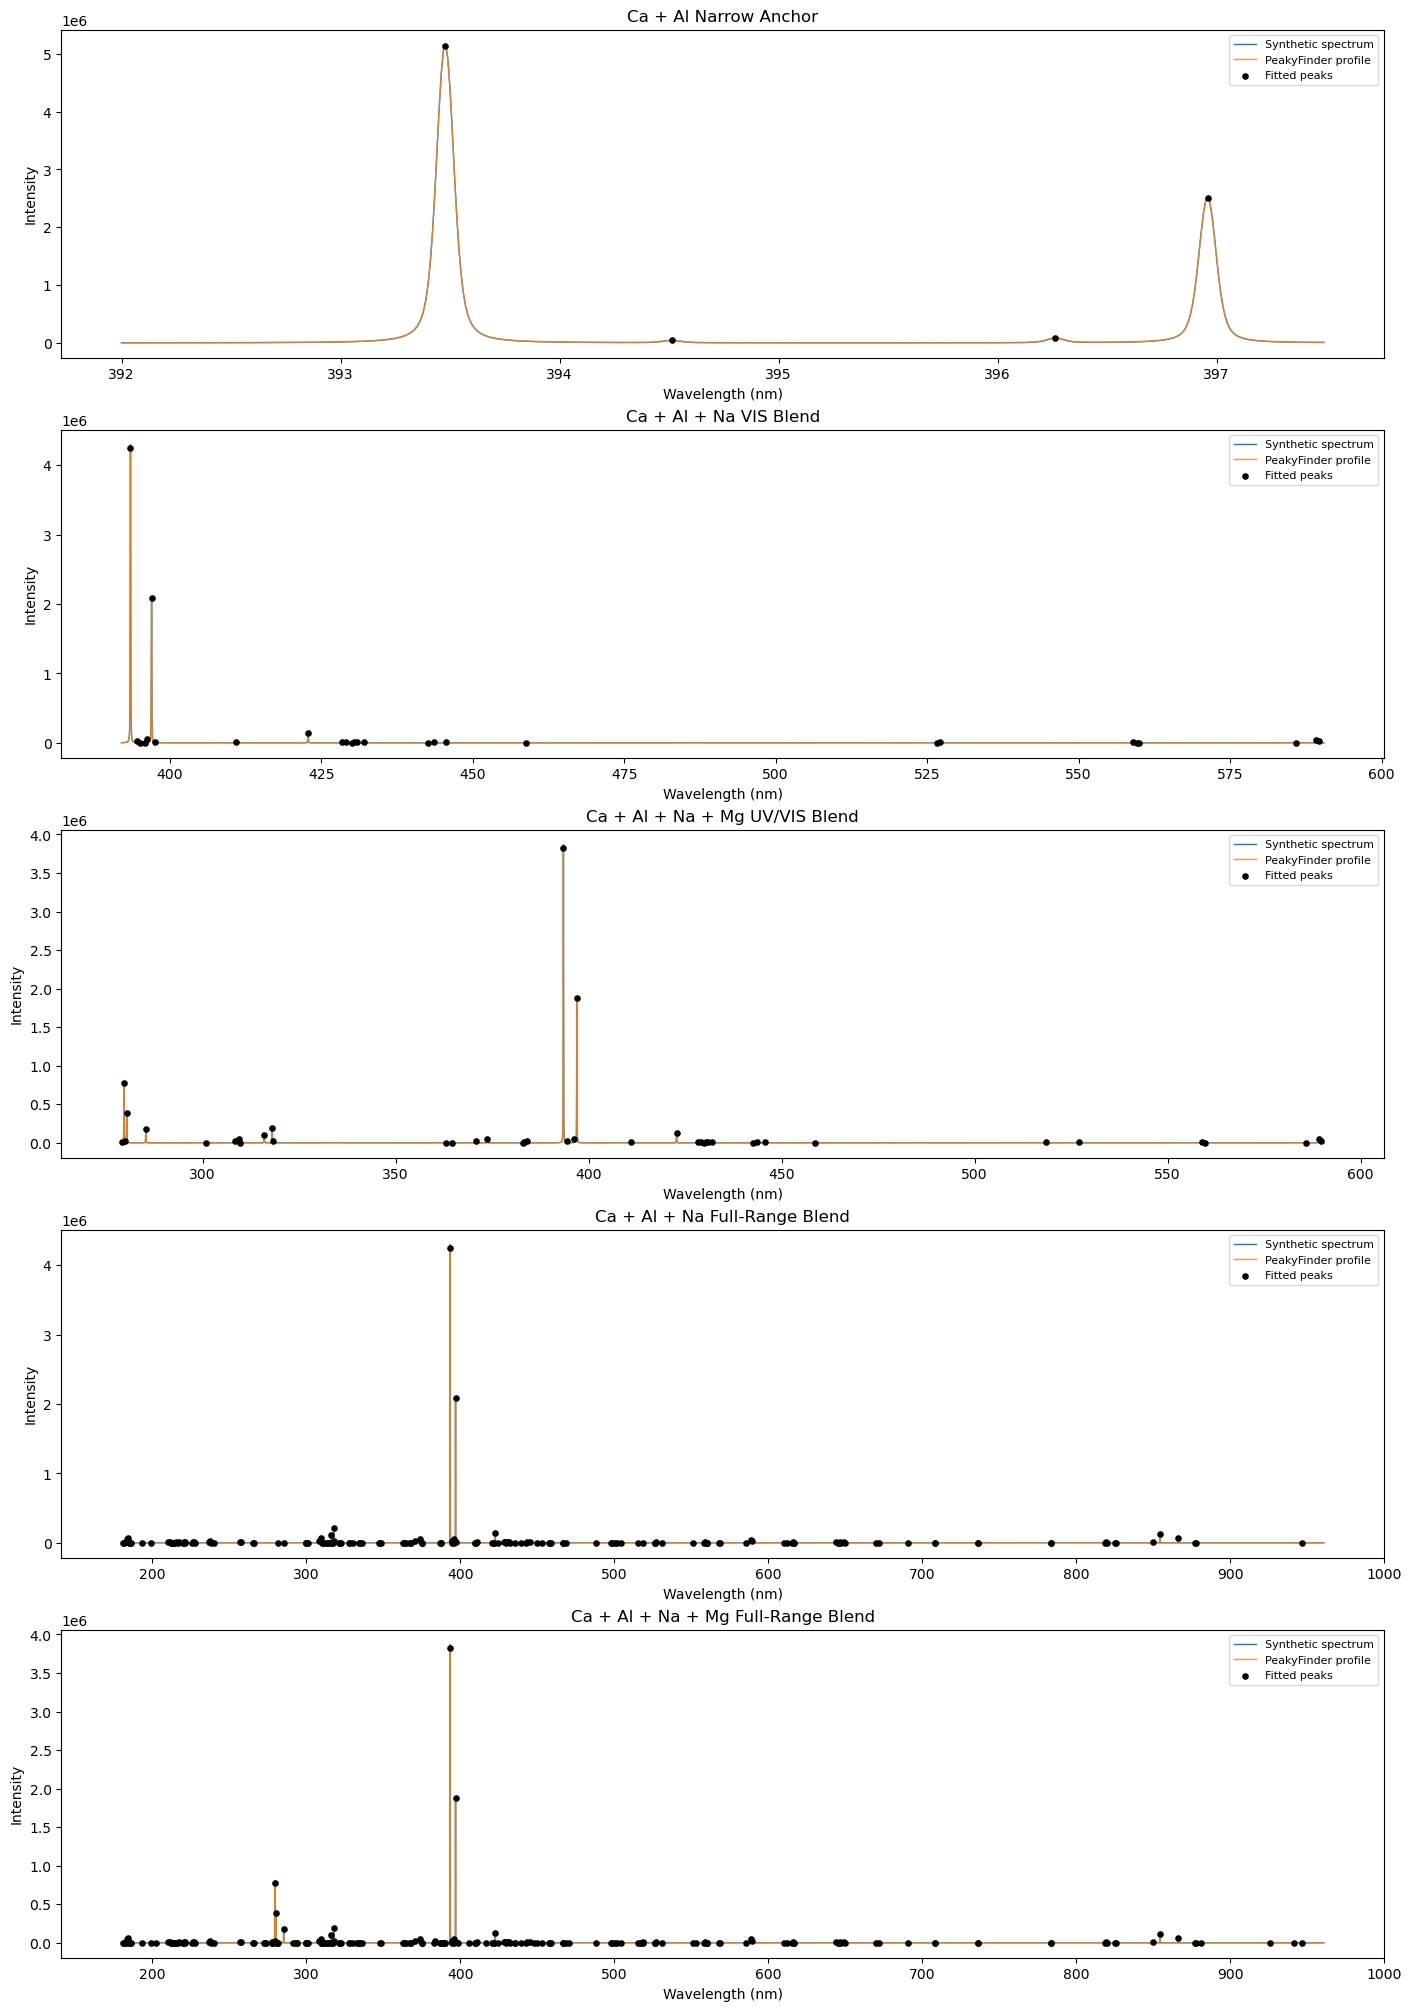

In [5]:
fig, axes = plt.subplots(len(runs), 1, figsize=(14, 4 * len(runs)), constrained_layout=True)
if len(runs) == 1:
    axes = [axes]

for ax, (case, run) in zip(axes, runs):
    plot_case(case, run, ax)

plt.show()


In [6]:
summary_rows = []

for case, run in runs:
    result = run["result"]
    summary_rows.append(
        {
            "case": case["name"],
            "peaks": int(run["peaks"].shape[0]),
            "active_species": len(run["ranked"]),
            "assigned_species": len(run["assigned"]),
            "temperature_K": round(float(result.temperature), 1),
            "log10_ne_cm^-3": round(float(result.ne), 3),
            "r_squared": round(float(result.r_squared), 6),
            "top_species": [
                species_label(element, ion)
                for element, ion, _ in unique_ranked_species(run["ranked"], case["top_n"])
            ],
        }
    )

summary_rows


[{'case': 'Ca + Al Narrow Anchor',
  'peaks': 4,
  'active_species': 2,
  'assigned_species': 2,
  'temperature_K': 10877.1,
  'log10_ne_cm^-3': 16.7,
  'r_squared': 0.999989,
  'top_species': ['Ca II', 'Al I']},
 {'case': 'Ca + Al + Na VIS Blend',
  'peaks': 27,
  'active_species': 4,
  'assigned_species': 4,
  'temperature_K': 10877.1,
  'log10_ne_cm^-3': 16.7,
  'r_squared': 0.999962,
  'top_species': ['Ca II', 'Ca I', 'Al I', 'Na I']},
 {'case': 'Ca + Al + Na + Mg UV/VIS Blend',
  'peaks': 42,
  'active_species': 6,
  'assigned_species': 6,
  'temperature_K': 10593.1,
  'log10_ne_cm^-3': 16.81,
  'r_squared': 0.999363,
  'top_species': ['Ca II', 'Mg II', 'Mg I', 'Ca I', 'Al I', 'Na I']},
 {'case': 'Ca + Al + Na Full-Range Blend',
  'peaks': 180,
  'active_species': 5,
  'assigned_species': 5,
  'temperature_K': 10593.1,
  'log10_ne_cm^-3': 16.81,
  'r_squared': 0.998382,
  'top_species': ['Ca II', 'Ca I', 'Al I', 'Na I', 'C I']},
 {'case': 'Ca + Al + Na + Mg Full-Range Blend',
  'p